# Final Presentation — Power System Simulation

**GridHub** — Timo van den Bos, Haroen Tmimi, Julian van den Hurk, Jasper Fortuin

This notebook demonstrates the full functionality of our `power_system_simulation` package
using the **big network** dataset (802 nodes, 807 lines, 400 households, 8 feeders).

## 1 — Setup & Data Loading

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from power_grid_model import ComponentType
from power_grid_model.utils import json_deserialize

from power_system_simulation.EV_Penetration import assign_ev_penetration, map_houses_per_feeder
from power_system_simulation.grid_model import (
    aggregate_line_results,
    aggregate_voltage_results,
    construct_model,
    create_batch_update,
    run_power_flow,
)
from power_system_simulation.lv_validation import validate_lv_grid_data
from power_system_simulation.n1_calculation import run_n1_analysis
from power_system_simulation.optimal_tap_position.optimal_position import get_optimal_tap
from power_system_simulation.optimal_tap_position.powerflow_calculation import run_powerflow_all_taps

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

In [2]:
# ── Point this to your local big_network folder ──
DATA_DIR = Path("/home/haroen/Documents/5XWG0/big_network/input")

# Load PGM grid
pgm_input = json_deserialize((DATA_DIR / "input_network_data.json").read_text())

# Load metadata
meta = json.loads((DATA_DIR / "meta_data.json").read_text())
feeder_ids = meta["lv_feeders"]

# Load profiles
active_full = pd.read_parquet(DATA_DIR / "active_power_profile.parquet")
reactive_full = pd.read_parquet(DATA_DIR / "reactive_power_profile.parquet")
ev_full = pd.read_parquet(DATA_DIR / "ev_active_power_profile.parquet")

# Time slice — one week (672 x 15 min) keeps demos fast (~2 s per power flow)
N_STEPS = 672
active = active_full.iloc[:N_STEPS]
reactive = reactive_full.iloc[:N_STEPS]
ev = ev_full.iloc[:N_STEPS]

tf = pgm_input[ComponentType.transformer]
print(f"Nodes:       {len(pgm_input[ComponentType.node])}")
print(f"Lines:       {len(pgm_input[ComponentType.line])}")
print(f"Sym loads:   {len(pgm_input[ComponentType.sym_load])}")
print(f"Feeders:     {feeder_ids}")
print(f"Transformer: id={meta['transformer']}, tap range [{tf['tap_max'][0]}..{tf['tap_min'][0]}]")
print(f"Time slice:  {active.index[0]}  to  {active.index[-1]}  ({N_STEPS} steps)")

Nodes:       802
Lines:       807
Sym loads:   400
Feeders:     [1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904]
Transformer: id=803, tap range [1..5]
Time slice:  2025-01-01 00:00:00  to  2025-01-07 23:45:00  (672 steps)


## 2 — Input Validation

In [3]:
validate_lv_grid_data(pgm_input, feeder_ids, active, reactive, ev)
print("All validation checks passed.")

All validation checks passed.


## 3 — Base Case Power Flow

Run a time-series power flow with the original grid and household load profiles (no EVs).

In [4]:
model = construct_model(pgm_input)
update_data, timestamps = create_batch_update(active, reactive)

t0 = time.time()
output = run_power_flow(model, pgm_input, update_data)
print(f"Power flow completed in {time.time() - t0:.2f} s")

voltage_df = aggregate_voltage_results(output, timestamps)
line_df = aggregate_line_results(output, timestamps)

print(f"\nVoltage range:      {voltage_df['Min_Voltage'].min():.4f} - {voltage_df['Max_Voltage'].max():.4f} p.u.")
print(f"Total energy loss:  {line_df['Total_Loss'].sum():.2f} kWh")
print(f"Peak line loading:  {line_df['Max_Loading'].max():.4f} p.u. (line {line_df['Max_Loading'].idxmax()})")

Power flow completed in 4.56 s

Voltage range:      1.0499 - 1.0756 p.u.
Total energy loss:  32.73 kWh
Peak line loading:  0.0217 p.u. (line 1906)


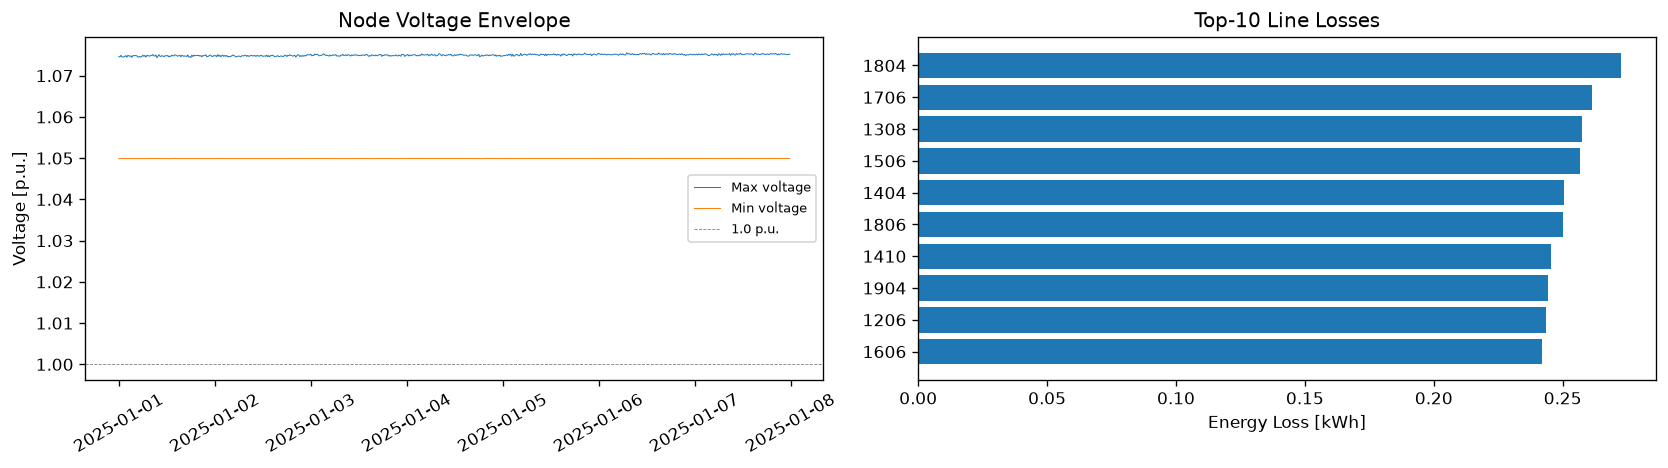

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Voltage envelope
ax1.plot(voltage_df.index, voltage_df["Max_Voltage"], label="Max voltage", linewidth=0.6)
ax1.plot(voltage_df.index, voltage_df["Min_Voltage"], label="Min voltage", linewidth=0.6)
ax1.axhline(1.0, color="grey", linestyle="--", linewidth=0.5, label="1.0 p.u.")
ax1.set_ylabel("Voltage [p.u.]")
ax1.set_title("Node Voltage Envelope")
ax1.legend(fontsize=8)
ax1.tick_params(axis="x", rotation=30)

# Top-10 line losses
top_loss = line_df.nlargest(10, "Total_Loss")["Total_Loss"]
ax2.barh(top_loss.index.astype(str), top_loss.values)
ax2.set_xlabel("Energy Loss [kWh]")
ax2.set_title("Top-10 Line Losses")
ax2.invert_yaxis()

fig.tight_layout()
plt.show()

## 4 — EV Penetration Analysis

Randomly assign EV charging profiles to households at different penetration levels
and compare the impact on voltages and line loading.

Per the specification, the number of EVs per feeder is
`floor(penetration_level * total_houses / n_feeders)`.

In [6]:
levels = [0.0, 0.3, 0.5, 0.7, 1.0]
ev_results = {}

for level in levels:
    t0 = time.time()
    vdf, ldf = assign_ev_penetration(
        input_data=pgm_input,
        feeder_ids=feeder_ids,
        active_load_profile=active,
        reactive_load_profile=reactive,
        ev_active_profile=ev,
        penetration_level=level,
        random_seed=42,
    )
    ev_results[level] = (vdf, ldf)
    print(
        f"EV {level * 100:5.1f}%  |  min V = {vdf['Min_Voltage'].min():.4f} p.u.  |  "
        f"max loading = {ldf['Max_Loading'].max():.4f} p.u.  |  {time.time() - t0:.1f} s"
    )

EV   0.0%  |  min V = 1.0499 p.u.  |  max loading = 0.0217 p.u.  |  4.2 s
EV  30.0%  |  min V = 1.0499 p.u.  |  max loading = 0.0472 p.u.  |  3.7 s
EV  50.0%  |  min V = 1.0498 p.u.  |  max loading = 0.0482 p.u.  |  3.7 s
EV  70.0%  |  min V = 1.0498 p.u.  |  max loading = 0.0671 p.u.  |  3.6 s
EV 100.0%  |  min V = 1.0497 p.u.  |  max loading = 0.0729 p.u.  |  3.6 s


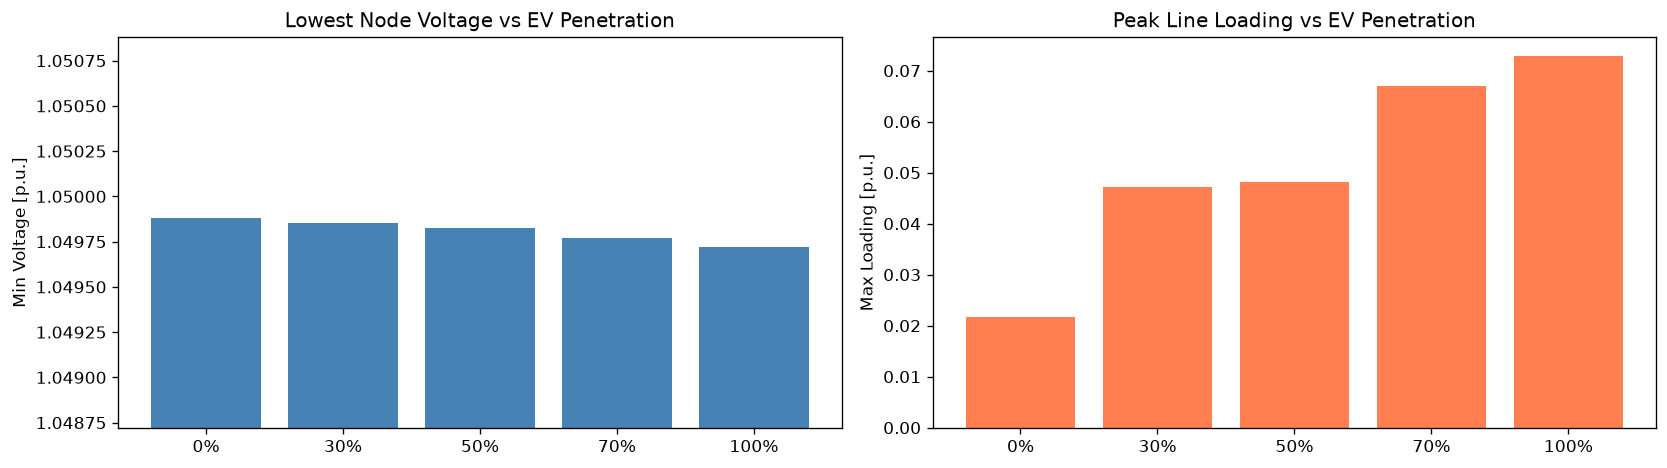

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

pct_labels = [f"{lv * 100:.0f}%" for lv in levels]
min_voltages = [ev_results[lv][0]["Min_Voltage"].min() for lv in levels]
max_loadings = [ev_results[lv][1]["Max_Loading"].max() for lv in levels]

ax1.bar(pct_labels, min_voltages, color="steelblue")
ax1.set_ylabel("Min Voltage [p.u.]")
ax1.set_title("Lowest Node Voltage vs EV Penetration")
ax1.set_ylim(min(min_voltages) - 0.001, max(min_voltages) + 0.001)

ax2.bar(pct_labels, max_loadings, color="coral")
ax2.set_ylabel("Max Loading [p.u.]")
ax2.set_title("Peak Line Loading vs EV Penetration")

fig.tight_layout()
plt.show()

### Feeder-to-household mapping

The EV function uses the graph processor to identify which loads belong to each feeder.

In [8]:
feeder_map = map_houses_per_feeder(pgm_input, feeder_ids)
for fid, loads in feeder_map.items():
    print(f"Feeder {fid}: {len(loads):>3} households")
print(f"\nTotal: {sum(len(v) for v in feeder_map.values())} households")

Feeder 1204:  50 households
Feeder 1304:  50 households
Feeder 1404:  50 households
Feeder 1504:  50 households
Feeder 1604:  50 households
Feeder 1704:  50 households
Feeder 1804:  50 households
Feeder 1904:  50 households

Total: 400 households


## 5 — Optimal Tap Position

Sweep all transformer tap positions and select the optimum by two criteria:
- **Losses** — minimal total line energy loss
- **Voltage** — minimal average deviation of node voltages from 1.0 p.u.

Note: these criteria may yield different optima, highlighting the trade-off
between loss minimization and voltage regulation.

In [9]:
tap_range = list(
    range(
        int(pgm_input[ComponentType.transformer]["tap_max"][0]),
        int(pgm_input[ComponentType.transformer]["tap_min"][0]) + 1,
    )
)
print(f"Tap positions to evaluate: {tap_range}")

t0 = time.time()
results_per_tap = run_powerflow_all_taps(
    pgm_input,
    tap_range,
    meta,
    active,
    reactive,
)
print(f"All {len(tap_range)} power flows completed in {time.time() - t0:.1f} s")

# Collect per-tap metrics
tap_losses = {}
tap_voltage_dev = {}
for tap, data in results_per_tap.items():
    ldf = aggregate_line_results(data["output_data"], data["timestamps"])
    vdf = aggregate_voltage_results(data["output_data"], data["timestamps"])
    tap_losses[tap] = ldf["Total_Loss"].sum()
    tap_voltage_dev[tap] = ((vdf["Max_Voltage"] - 1).abs() + (vdf["Min_Voltage"] - 1).abs()).mean()

for tap in tap_range:
    print(f"  Tap {tap}:  loss = {tap_losses[tap]:.2f} kWh  |  voltage dev = {tap_voltage_dev[tap]:.6f}")

Tap positions to evaluate: [1, 2, 3, 4, 5]
All 5 power flows completed in 17.5 s
  Tap 1:  loss = 35.84 kWh  |  voltage dev = 0.073651
  Tap 2:  loss = 34.27 kWh  |  voltage dev = 0.097727
  Tap 3:  loss = 32.73 kWh  |  voltage dev = 0.124913
  Tap 4:  loss = 31.22 kWh  |  voltage dev = 0.150581
  Tap 5:  loss = 29.76 kWh  |  voltage dev = 0.177499


In [10]:
best_loss_tap = get_optimal_tap(
    pgm_input,
    tap_range,
    "losses",
    meta,
    active,
    reactive,
)
best_volt_tap = get_optimal_tap(
    pgm_input,
    tap_range,
    "voltage",
    meta,
    active,
    reactive,
)

print(f"Optimal tap (minimal losses):            {best_loss_tap}")
print(f"Optimal tap (minimal voltage deviation):  {best_volt_tap}")

Optimal tap (minimal losses):            5
Optimal tap (minimal voltage deviation):  1


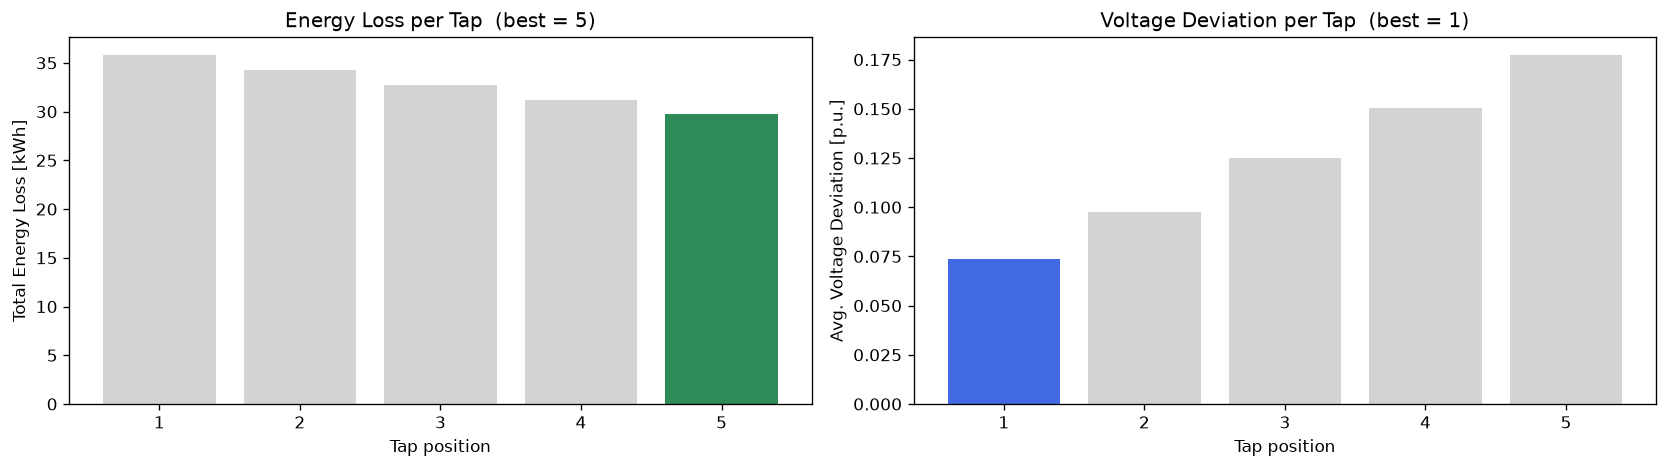

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

taps = list(tap_losses.keys())
colors_loss = ["seagreen" if t == best_loss_tap else "lightgrey" for t in taps]
colors_volt = ["royalblue" if t == best_volt_tap else "lightgrey" for t in taps]

ax1.bar([str(t) for t in taps], [tap_losses[t] for t in taps], color=colors_loss)
ax1.set_xlabel("Tap position")
ax1.set_ylabel("Total Energy Loss [kWh]")
ax1.set_title(f"Energy Loss per Tap  (best = {best_loss_tap})")

ax2.bar(
    [str(t) for t in taps],
    [tap_voltage_dev[t] for t in taps],
    color=colors_volt,
)
ax2.set_xlabel("Tap position")
ax2.set_ylabel("Avg. Voltage Deviation [p.u.]")
ax2.set_title(f"Voltage Deviation per Tap  (best = {best_volt_tap})")

fig.tight_layout()
plt.show()

## 6 — N-1 Contingency Analysis

Take a connected line out of service, find which currently-disconnected line
can restore full connectivity (using `find_alternative_edges` from Assignment 1),
and evaluate the resulting loading for each alternative topology.

In [12]:
# Pick a line on the ring that has an alternative
failed_line = 1206
lines = pgm_input[ComponentType.line]
idx = int(np.where(lines["id"] == failed_line)[0][0])
print(f"Failing line {failed_line}  (node {lines['from_node'][idx]} -> {lines['to_node'][idx]})")

t0 = time.time()
n1_result = run_n1_analysis(
    pgm_input,
    active,
    reactive,
    failed_line_id=failed_line,
)
print(f"N-1 analysis completed in {time.time() - t0:.1f} s\n")
n1_result

Failing line 1206  (node 2 -> 4)
N-1 analysis completed in 3.5 s



,Alternative_Line_ID,Max_Loading,Max_Loading_Line_ID,Max_Loading_Timestamp
0,2004,0.038405,1310,2025-01-01 04:15:00


### N-1 on a leaf line (no alternative)

Lines that feed leaf nodes have no ring-closure alternative.
The function correctly returns an empty table with the right column headings.

In [13]:
leaf_line = 1205
n1_empty = run_n1_analysis(
    pgm_input,
    active,
    reactive,
    failed_line_id=leaf_line,
)
print(f"Line {leaf_line}: {len(n1_empty)} alternative(s)")
n1_empty

Line 1205: 0 alternative(s)


,Alternative_Line_ID,Max_Loading,Max_Loading_Line_ID,Max_Loading_Timestamp


## 7 — Summary

| Functionality | Key Result |
|---|---|
| **Validation** | All input checks passed |
| **Base case** | Voltage envelope and line losses computed over one week |
| **EV penetration** | Peak loading scales 3x from 0% to 100% penetration |
| **Optimal tap** | Losses and voltage criteria give opposite optima (trade-off) |
| **N-1 analysis** | Alternative topologies identified and evaluated |